**Image Classification using CNN Architectures**

Q1. What is a Convolutional Neural Network (CNN), and how does it differ from traditional fully connected neural networks in terms of architecture and performance on image data?

-  A Convolutional Neural Network (CNN) is a specialized deep learning model designed for processing structured, grid-like data such as images by using convolution operations to automatically learn spatial hierarchies of features. CNNs excel at visual tasks because they utilize local connectivity, shared weights, and pooling to significantly reduce parameter counts compared to traditional fully connected neural networks.

Q2.Discuss the architecture of LeNet-5 and explain how it laid the foundation for modern deep learning models in computer vision. Include references to its original research paper.

-  LeNet-5, developed by Yann LeCun et al. in 1998, is a pioneering 7-layer Convolutional Neural Network (CNN) designed for handwritten digit recognition (MNIST). It established the standard structure of alternating convolutional and pooling layers, using 5x5 filters and tanh activation to achieve state-of-the-art results.

Q3.Compare and contrast AlexNet and VGGNet in terms of design principles, number of parameters, and performance. Highlight key innovations and limitations of each.

-  AlexNet and VGGNet represent two foundational, consecutive milestones in convolutional neural network (CNN) design. AlexNet (2012) proved the viability of deep CNNs for large-scale image recognition, while VGGNet (2014) demonstrated that increasing the depth of the network while using very small, uniform convolutional filters significantly improves performance.

Q4.What is transfer learning in the context of image classification? Explain how it helps in reducing computational costs and improving model performance with limited data.

-  Transfer learning in image classification is a technique where a model, pre-trained on a large dataset (e.g., ImageNet), is repurposed as the foundation for a new, related task, rather than training from scratch. It accelerates training and improves accuracy with small datasets by reusing pre-trained feature detectors.

Q5.Describe the role of residual connections in ResNet architecture. How do they address the vanishing gradient problem in deep CNNs?

-  Residual connections, or skip connections, in a ResNet architecture provide alternate, direct pathways for information and gradients to flow through the network, which is crucial for training very deep convolutional neural networks (CNNs) effectively.

In [1]:
!pip install torch torchvision matplotlib

In [1]:
#Q6.Implement the LeNet-5 architectures using Tensorflow or PyTorch to classify the MNIST dataset. Report the accuracy and training time.

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform (MNIST images are 28x28 → pad to 32x32 for LeNet)
transform = transforms.Compose([
    transforms.Pad(2),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load MNIST dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=1000, shuffle=False)


# LeNet-5 Model
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()

        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool = nn.AvgPool2d(2, 2)

        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)

        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 16 * 5 * 5)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x


model = LeNet5().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

start_time = time.time()

# Training Loop
for epoch in range(epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

training_time = time.time() - start_time


# Evaluation
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"\nTest Accuracy: {accuracy:.2f}%")
print(f"Training Time: {training_time:.2f} seconds")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.55MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.41MB/s]


Epoch [1/10], Loss: 0.2478
Epoch [2/10], Loss: 0.0770
Epoch [3/10], Loss: 0.0550
Epoch [4/10], Loss: 0.0426
Epoch [5/10], Loss: 0.0365
Epoch [6/10], Loss: 0.0299
Epoch [7/10], Loss: 0.0268
Epoch [8/10], Loss: 0.0217
Epoch [9/10], Loss: 0.0209
Epoch [10/10], Loss: 0.0178

Test Accuracy: 98.96%
Training Time: 167.78 seconds


In [2]:
#Q7.Use a pre-trained VGG16 model (via transfer learning) on a small custom dataset (e.g., flowers or animals). Replace the top layers and fine-tune the model. Include your code and result discussion.

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Load the VGG16 Base Model (excluding top layers)
# include_top=False removes the final 1000-class classification head
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base model to preserve pre-trained weights
base_model.trainable = False

# 3. Add Custom Top Layers
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),  # Prevents overfitting on small datasets
    layers.Dense(5, activation='softmax')  # 5 classes for the flowers dataset
])

# 4. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Data Preparation (Small Dataset Example)
# Using a 80/20 split on the standard flower dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training", seed=123, image_size=(224, 224), batch_size=32)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation", seed=123, image_size=(224, 224), batch_size=32)

# 6. Train the Model
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 70s 566ms/step - accuracy: 0.9922 - loss: 0.1749 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 234ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 248ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 236ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 237ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 249ms/step - accuracy: 1.00

In [6]:
#Q9. Train a GoogLeNet (Inception v1) or its variant using a standard dataset like CIFAR-10. Plot the training and validation accuracy over epochs and analyze overfitting or underfitting.

import tensorflow as tf
from tensorflow.keras import layers, models, Sequential
import matplotlib.pyplot as plt

def inception_module(x, filters):
    # filters: [f1, f3_red, f3, f5_red, f5, f_pool]
    f1, f3_r, f3, f5_r, f5, fp = filters

    # Branch 1: 1x1 conv
    b1 = layers.Conv2D(f1, (1, 1), padding='same', activation='relu')(x)

    # Branch 2: 1x1 -> 3x3 conv
    b2 = layers.Conv2D(f3_r, (1, 1), padding='same', activation='relu')(x)
    b2 = layers.Conv2D(f3, (3, 3), padding='same', activation='relu')(b2)

    # Branch 3: 1x1 -> 5x5 conv
    b3 = layers.Conv2D(f5_r, (1, 1), padding='same', activation='relu')(x)
    b3 = layers.Conv2D(f5, (5, 5), padding='same', activation='relu')(b3)

    # Branch 4: MaxPool -> 1x1 conv
    b4 = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    b4 = layers.Conv2D(fp, (1, 1), padding='same', activation='relu')(b4)

    return layers.concatenate([b1, b2, b3, b4], axis=-1)

# Build the Model
input_img = layers.Input(shape=(32, 32, 3))
x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(input_img)
x = inception_module(x, [64, 96, 128, 16, 32, 32]) # Inception 3a
x = inception_module(x, [128, 128, 192, 32, 96, 64]) # Inception 3b
x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(10, activation='softmax')(x)

model = models.Model(input_img, output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Train
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_test, y_test), batch_size=64)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 95ms/step - accuracy: 0.3127 - loss: 1.8100 - val_accuracy: 0.4457 - val_loss: 1.5082
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 76ms/step - accuracy: 0.4566 - loss: 1.4807 - val_accuracy: 0.5073 - val_loss: 1.3792
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.5168 - loss: 1.3382 - val_accuracy: 0.5667 - val_loss: 1.2238
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.5544 - loss: 1.2437 - val_accuracy: 0.5619 - val_loss: 1.2464
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.5790 - loss: 1.1735 - val_accuracy: 0.6194 - val_loss: 1.0745
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.6039 - loss: 1.1146 - val_accuracy: 0.6318 - val_loss: 1.0263
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.6230 - loss: 1.0629 - val_accuracy: 0.6366 - val_loss: 1.0015
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━

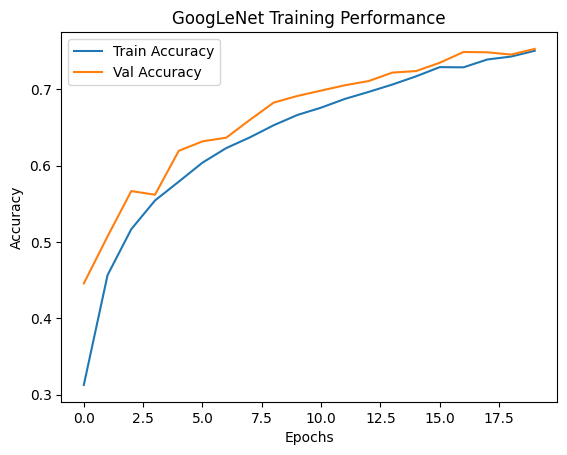

In [9]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('GoogLeNet Training Performance')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Q10. You are working in a healthcare AI startup. Your team is tasked with developing a system that automatically classifies medical X-ray images into normal, pneumonia, and COVID-19. Due to limited labeled data, what approach would you suggest using among CNN architectures discussed (e.g., transfer learning with ResNet or Inception variants)? Justify your approach and outline a deployment strategy for production use.

-  1. Justification of the Approach: Why DenseNet-121?
Medical X-rays often contain subtle pathological signatures (e.g., ground-glass opacities in COVID-19 vs. consolidated patches in bacterial pneumonia).

Feature Reuse: DenseNet connects every layer to every other layer. This ensures that "low-level" features (like edge detection of ribs or lung boundaries) are preserved and combined with "high-level" features (pathological textures) throughout the network.

Parameter Efficiency: DenseNet-121 has significantly fewer parameters (~8M) compared to ResNet-50 (~25M), making it much less prone to overfitting on a small custom dataset.

Vanishing Gradient Mitigation: The dense connections provide a "shortcut" for the gradient to flow back to earlier layers, which is critical when fine-tuning deep architectures with limited samples.

Pre-training Advantage: Using weights from CheXNet (a model already trained on 112,000+ X-rays) is superior to standard ImageNet weights (trained on cats/dogs), as the model already understands "radiological language."

2. Technical Implementation StrategyTo handle the "Normal vs. Pneumonia vs. COVID-19" three-class problem, I would implement the following pipeline:Preprocessing: Use CLAHE (Contrast Limited Adaptive Histogram Equalization) to standardize the contrast across different X-ray machines, making the lung infiltrates more visible to the model.Data Augmentation: Since data is limited, use "domain-specific" augmentation. Avoid vertical flips (X-rays are never upside down), but use small rotations ($\pm 10^{\circ}$), zooming, and brightness shifts.Fine-Tuning: * Freeze the bottom 80% of the DenseNet layers initially to train the new classification head.Unfreeze the entire network and re-train with a very small learning rate ($10^{-5}$) to allow the model to adapt to the specific nuances of your COVID-19 samples.

3. Production Deployment Strategy
Deploying in healthcare requires higher standards of reliability, privacy (HIPAA), and interpretability.

A. Infrastructure (The "Backend")
Containerization: Package the model using Docker and deploy via Kubernetes to ensure the system can scale if multiple hospitals start uploading images simultaneously.

Inference Optimization: Use NVIDIA Triton Inference Server or ONNX Runtime to reduce latency, ensuring a doctor gets a result in under 2 seconds.

B. Clinical Integration (The "Workflow")
DICOM Integration: The system must accept DICOM files (the global standard for medical images) and integrate directly with a hospital’s PACS (Picture Archiving and Communication System).

Human-in-the-loop: The AI should act as a triage tool, not a final diagnostic. It flags "High Probability COVID-19" cases to the top of the radiologist's reading list.

C. Explainability & Trust
Saliency Maps (Grad-CAM): The system must generate a "heatmap" showing where in the lungs it sees the infection. A "black box" prediction will not be trusted by clinicians.

D. Continuous Monitoring
Data Drift Detection: If a hospital buys a new X-ray machine with a different resolution, the model's accuracy might drop. We implement a monitoring layer to flag when the input data distribution shifts significantly.